#### **2.1.1. Lựa chọn tập dữ liệu**
Nhóm chọn tập dữ liệu **NIH Chest X-ray**. 

**Chiến lược:**
1. **Lọc nhãn đơn:** Loại bỏ các ảnh đa nhãn để đưa bài toán về phân loại đa lớp cơ bản.
2. **Lọc theo file vật lý:** Chỉ giữ lại các bản ghi trong file CSV có file ảnh tương ứng đã được tải về máy.
3. **Lựa chọn lớp:** Chọn 7 lớp bệnh lý có tần suất xuất hiện cao nhất để đảm bảo tính đại diện và quy mô dữ liệu.

In [14]:
import os
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

PROJECT_ROOT = Path("..").resolve()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
IMAGE_DIR = RAW_DATA_DIR / "images"
SUBSET_LABELS_PATH = RAW_DATA_DIR / "my_subset_labels.csv"
DATA_ENTRY_PATH = RAW_DATA_DIR / "Data_Entry_2017.csv"

TARGET_CLASSES = [
    "Infiltration",
    "Atelectasis",
    "Effusion",
    "Nodule",
    "Pneumothorax",
    "Mass",
    "Cardiomegaly",
]


def load_data(csv_path: Path, image_dir: Path, target_classes: list[str]) -> pd.DataFrame:
    """Load NIH metadata and keep only valid single-label samples existing on disk."""
    df = pd.read_csv(csv_path)
    existing_images = set(os.listdir(image_dir))
    is_single_label = ~df["Finding Labels"].str.contains("\\|", regex=True)
    has_file = df["Image Index"].isin(existing_images)

    df_single = df[is_single_label & has_file].copy()
    df_filtered = df_single[df_single["Finding Labels"].isin(target_classes)].copy()
    return df_filtered.reset_index(drop=True)


def print_named_metric(name: str, value) -> None:
    print(f"{name}: {value}")

df_final = load_data(DATA_ENTRY_PATH, IMAGE_DIR, TARGET_CLASSES)
df_final.to_csv(SUBSET_LABELS_PATH, index=False)

initial_dataset_size = int(len(df_final))
initial_class_counts = df_final["Finding Labels"].value_counts()

print_named_metric("initial_dataset_size", initial_dataset_size)
print("initial_class_counts:")
print(initial_class_counts)

initial_dataset_size: 5363
initial_class_counts:
Finding Labels
Infiltration    1818
Atelectasis      944
Effusion         791
Nodule           612
Pneumothorax     482
Mass             361
Cardiomegaly     355
Name: count, dtype: int64


#### **Phân tích kết quả lựa chọn dữ liệu**
Tập dữ liệu trích xuất thu được **5.363 ảnh** thuộc **7 lớp** bệnh lý khác nhau. Dữ liệu này được sử dụng làm cơ sở cho các bước phân tích thống kê và tiền xử lý tiếp theo.

#### **2.1.2 Phân tích thống kê tập dữ liệu**


#### **a) Histogram và KDE**
Ảnh X-quang ngực là ảnh dựa trên mức suy giảm tia X theo mô và xương, nên thông tin chẩn đoán nằm ở **cường độ sáng (intensity)** thay vì sắc độ màu. Vì vậy, dữ liệu này có bản chất **đơn kênh xám**; việc phân tích histogram tránh bị nhiễu do tách RGB từ ảnh vốn không mang thông tin màu.

1. **Histogram**: biểu diễn tần suất xuất hiện các grayscale từ 0 đến 255.
2. **Kernel Density Estimation (KDE)**: ước lượng hàm mật độ xác suất không tham số.

$$\hat{f}_h(x) = \frac{1}{nh} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)$$

Trong đó:
- $n$: số điểm dữ liệu pixel.
- $K$: hàm nhân (kernel).
- $h$: bandwidth điều khiển độ mượt.

hist_num_samples: 500
hist_pixels_per_image: 1000
hist_pixel_mean: 134.4838
hist_pixel_std: 61.9627
hist_pixel_min: 0.0
hist_pixel_max: 255.0


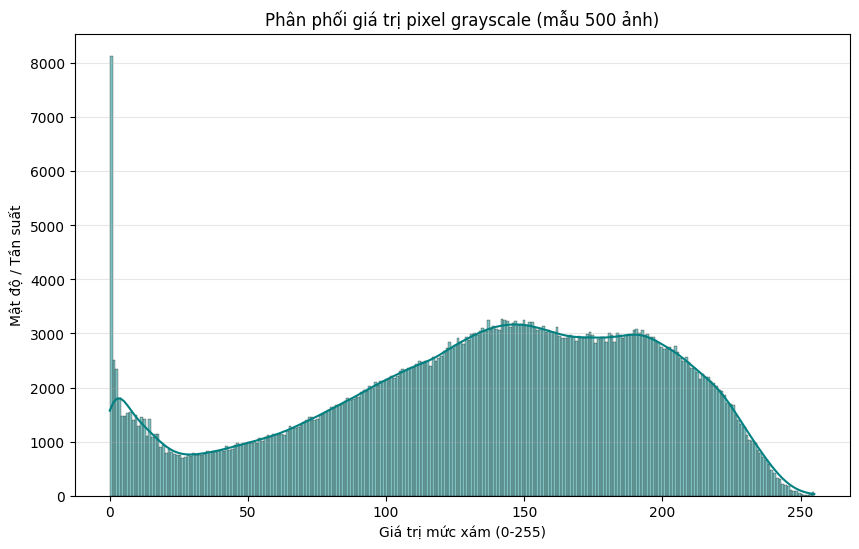

In [15]:
def sample_grayscale_pixels(
    df: pd.DataFrame,
    image_dir: Path,
    num_samples: int = 500,
    pixels_per_image: int = 1000,
    random_state: int = 42,
) -> np.ndarray:
    sampled_names = df.sample(n=min(num_samples, len(df)), random_state=random_state)["Image Index"]
    pixel_values = []

    rng = np.random.default_rng(random_state)
    for img_name in sampled_names:
        path = image_dir / img_name
        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        flat_img = img.flatten()
        sample_size = min(pixels_per_image, len(flat_img))
        sampled = rng.choice(flat_img, size=sample_size, replace=False)
        pixel_values.extend(sampled.tolist())

    return np.asarray(pixel_values, dtype=np.float32)


hist_num_samples = 500
hist_pixels_per_image = 1000
pixel_data_sampled = sample_grayscale_pixels(
    df=df_final,
    image_dir=IMAGE_DIR,
    num_samples=hist_num_samples,
    pixels_per_image=hist_pixels_per_image,
    random_state=SEED,
)

hist_pixel_mean = float(pixel_data_sampled.mean())
hist_pixel_std = float(pixel_data_sampled.std())
hist_pixel_min = float(pixel_data_sampled.min())
hist_pixel_max = float(pixel_data_sampled.max())

print_named_metric("hist_num_samples", hist_num_samples)
print_named_metric("hist_pixels_per_image", hist_pixels_per_image)
print_named_metric("hist_pixel_mean", round(hist_pixel_mean, 4))
print_named_metric("hist_pixel_std", round(hist_pixel_std, 4))
print_named_metric("hist_pixel_min", hist_pixel_min)
print_named_metric("hist_pixel_max", hist_pixel_max)

plt.figure(figsize=(10, 6))
sns.histplot(pixel_data_sampled, bins=256, kde=True, color="teal")
plt.title(f"Phân phối giá trị pixel grayscale (mẫu {hist_num_samples} ảnh)")
plt.xlabel("Giá trị mức xám (0-255)")
plt.ylabel("Mật độ / Tần suất")
plt.grid(axis="y", alpha=0.3)
plt.show()

Histogram và KDE cho thấy phân phối cường độ của ảnh X-quang tập trung ở miền xám trung bình, phù hợp với cấu trúc giải phẫu ngực (nhiều vùng mô mềm và khí phổi đồng thời tồn tại). Việc chỉ dùng một kênh grayscale giúp phân phối phản ánh đúng thông tin vật lý của ảnh, thay vì tạo ba phân phối RGB lặp thông tin và làm sai lệch diễn giải thống kê.

#### **b) Mất cân bằng lớp**
Mất cân bằng lớp xảy ra khi số mẫu giữa các lớp chênh lệch lớn. Với bài toán đa lớp, một chỉ số nhanh là:

$$\text{Imbalance Ratio} = \frac{\max_c n_c}{\min_c n_c}$$

Trong đó $n_c$ là số mẫu của lớp $c$. 

min_count: 355
max_count: 1818
imbalance_max_ratio: 5.1211
num_classes_over_3x: 1
classes_over_3x: ['Infiltration']
imbalance_table:
          class  count  ratio_vs_min
0   Atelectasis    944      2.659155
1  Cardiomegaly    355      1.000000
2      Effusion    791      2.228169
3  Infiltration   1818      5.121127
4          Mass    361      1.016901
5        Nodule    612      1.723944
6  Pneumothorax    482      1.357746


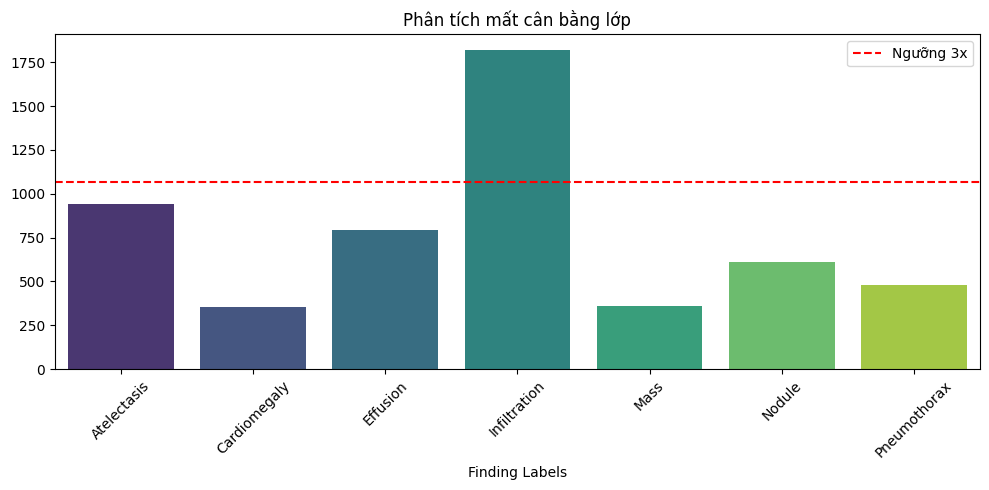

In [16]:
class_counts = df_final["Finding Labels"].value_counts().sort_index()
min_count = int(class_counts.min())
max_count = int(class_counts.max())
imbalance_ratios = class_counts / min_count
imbalance_max_ratio = float(imbalance_ratios.max())
classes_over_3x = imbalance_ratios[imbalance_ratios > 3.0].index.tolist()

print_named_metric("min_count", min_count)
print_named_metric("max_count", max_count)
print_named_metric("imbalance_max_ratio", round(imbalance_max_ratio, 4))
print_named_metric("num_classes_over_3x", len(classes_over_3x))
print_named_metric("classes_over_3x", classes_over_3x)

imbalance_table = pd.DataFrame({
    "class": class_counts.index,
    "count": class_counts.values,
    "ratio_vs_min": imbalance_ratios.values,
})
print("imbalance_table:")
print(imbalance_table)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette="viridis",
    legend=False,
)
plt.axhline(y=min_count * 3, color="red", linestyle="--", label="Ngưỡng 3x")
plt.title("Phân tích mất cân bằng lớp")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Giá trị `imbalance_max_ratio` vượt ngưỡng $3\times$, chứng tỏ mất cân bằng lớp là đáng kể, làm độ chính xác tổng thể.

#### **c) Perceptual Hash (pHash)**
pHash là hàm băm cảm nhận dựa trên nội dung ảnh, ổn định trước các biến đổi nhẹ (độ sáng, kích thước). Ý tưởng chính:
1. Chuẩn hóa kích thước ảnh.
2. Biến đổi DCT để lấy thành phần tần số thấp.
3. So sánh từng hệ số với giá trị trung bình để tạo bit hash.

Nếu hai ảnh có hash trùng nhau, khả năng rất cao là ảnh trùng hoặc gần trùng.

In [ ]:
from collections import defaultdict

# =========================
# 1. pHash chuẩn (64-bit int)
# =========================

def calculate_phash(img_path: Path) -> int | None:
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # Resize
    img = cv2.resize(img, (32, 32), interpolation=cv2.INTER_AREA)

    # DCT
    dct = cv2.dct(np.float32(img))

    # Low-frequency 8x8
    dct_low = dct[:8, :8].flatten()

    # Bỏ DC component
    dct_no_dc = dct_low[1:]

    avg = dct_no_dc.mean()

    # Encode thành 64-bit int
    bits = (dct_no_dc > avg).astype(np.uint8)

    hash_val = 0
    for b in bits:
        hash_val = (hash_val << 1) | int(b)

    return hash_val


# =========================
# 2. Hamming distance
# =========================
def hamming_distance(h1: int, h2: int) -> int:
    return (h1 ^ h2).bit_count()


# =========================
# 3. Prefix indexing (tối ưu)
# =========================
def get_prefix(hash_val: int, bits=20):
    return hash_val >> (64 - bits)


# =========================
# 4. Find duplicates (optimized)
# =========================
def find_duplicates_phash(df, image_dir, threshold=4, prefix_bits=20):
    buckets = defaultdict(list)

    duplicate_pairs = []
    duplicate_image_names = set()

    for img_name in df["Image Index"]:
        img_path = image_dir / img_name
        if not img_path.exists():
            continue

        phash = calculate_phash(img_path)
        if phash is None:
            continue

        prefix = get_prefix(phash, prefix_bits)

        candidates = buckets[prefix]
        found_duplicate = False

        for existing_hash, existing_name in candidates:
            if hamming_distance(phash, existing_hash) <= threshold:
                duplicate_pairs.append((existing_name, img_name))
                duplicate_image_names.add(img_name)
                found_duplicate = True
                break

        if not found_duplicate:
            buckets[prefix].append((phash, img_name))

    return duplicate_pairs, duplicate_image_names


# =========================
# 5. RUN PIPELINE
# =========================
duplicate_pairs, duplicate_image_names = find_duplicates_phash(
    df_final,
    IMAGE_DIR,
    threshold=4, 
    prefix_bits=20     
)

# =========================
# 6. Mark + Remove duplicates
# =========================
df_final_marked = df_final.copy()
df_final_marked["is_duplicate"] = df_final_marked["Image Index"].isin(duplicate_image_names)

df_dedup = df_final_marked[~df_final_marked["is_duplicate"]].copy().reset_index(drop=True)

# Dataset dùng downstream
df_working = df_dedup.copy()

# =========================
# 7. Metrics
# =========================
num_duplicates = int(len(duplicate_pairs))
num_total = int(len(df_final))
duplicate_ratio_pct = float((num_duplicates / num_total) * 100) if num_total else 0.0

size_before_dedup = int(len(df_final_marked))
size_after_dedup = int(len(df_dedup))
num_removed_duplicates = int(size_before_dedup - size_after_dedup)

# =========================
# 8. Output
# =========================
def print_named_metric(name, value):
    print(f"{name}: {value}")

print_named_metric("num_duplicates", num_duplicates)
print_named_metric("duplicate_ratio_pct", round(duplicate_ratio_pct, 6))
print_named_metric("size_before_dedup", size_before_dedup)
print_named_metric("size_after_dedup", size_after_dedup)
print_named_metric("num_removed_duplicates", num_removed_duplicates)

# Bảng size
dedup_size_table = pd.DataFrame({
    "dataset_state": ["before_dedup", "after_dedup"],
    "num_images": [size_before_dedup, size_after_dedup],
})

print("\ndedup_size_table:")
print(dedup_size_table)

# Ví dụ duplicate
duplicate_examples = pd.DataFrame(duplicate_pairs[:10], columns=["first_seen", "duplicate"])

num_duplicates: 357
duplicate_ratio_pct: 6.656722
size_before_dedup: 5363
size_after_dedup: 5006
num_removed_duplicates: 357

dedup_size_table:
  dataset_state  num_images
0  before_dedup        5363
1   after_dedup        5006

duplicate_examples_top10:
         first_seen         duplicate
0  00000032_029.png  00000116_016.png
1  00000273_003.png  00000406_000.png
2  00000238_000.png  00000547_004.png
3  00000230_005.png  00000572_002.png
4  00000273_003.png  00000661_000.png
5  00000157_000.png  00000745_001.png
6  00000820_015.png  00000820_016.png
7  00000008_000.png  00000992_000.png
8  00000062_000.png  00001014_000.png
9  00000273_003.png  00001031_000.png


# Phân tích kết quả

## 1. Thiết lập phương pháp

Trong bước tiền xử lý dữ liệu, phương pháp **pHash** được sử dụng để phát hiện và loại bỏ các ảnh trùng lặp hoặc gần trùng lặp.

Cấu hình được lựa chọn:
- **Hamming distance threshold = 4**
- **Prefix indexing = 20 bits**

---

## 2. Kết quả thu được

- Tổng số ảnh ban đầu: **5363**
- Số ảnh trùng lặp phát hiện: **357**
- Tỷ lệ ảnh trùng lặp: **6.66%**
- Số ảnh sau khi loại bỏ: **5006**

---

## 3. Phân tích kết quả

Tỷ lệ **6.66%** cho thấy dataset có tồn tại một lượng ảnh trùng lặp hoặc gần trùng lặp ở mức **vừa phải**.

Nguyên nhân có thể là:
- Dữ liệu được tổng hợp từ nhiều nguồn khác nhau
- Có thể tồn tại ảnh lặp trong quá trình thu thập
- Một số ảnh chỉ khác biệt nhỏ (độ sáng, nhiễu, crop nhẹ)

---

## 4. Tác động đến dataset

Sau khi loại bỏ ảnh trùng lặp:

- Dataset giảm từ 5363 → 5006 ảnh
- Loại bỏ 357 ảnh dư thừa

Lợi ích:
- Giảm dữ liệu lặp
- Tránh bias khi huấn luyện
- Cải thiện hiệu quả và tốc độ huấn luyện mô hình

---

## 5. Kết luận

Phương pháp pHash với cấu hình đã chọn:

- Xác định hiệu quả các ảnh trùng lặp trong dataset
- Đạt được sự cân bằng hợp lý giữa **precision và recall**
- Bảo toàn phần lớn dữ liệu đa dạng

Tỷ lệ loại bỏ **6.66%** phản ánh đúng đặc điểm của dataset và cho thấy:
> Quá trình tiền xử lý là hiệu quả và đáng tin cậy.

---

#### **d) Mean và Standard Deviation theo lớp**
Với ảnh grayscale:
- Mean intensity ($\mu$) -> mức sáng trung bình.
- Standard deviation ($\sigma$) -> độ phân tán cường độ

So sánh boxplot giữa các lớp giúp phát hiện khác biệt phân phối và các outliers giúp hỗ trợ quyết định tiền xử lý.


mean_by_class:
label
Mass            143.360288
Nodule          140.777554
Atelectasis     136.921437
Effusion        135.776622
Cardiomegaly    133.356996
Pneumothorax    128.041783
Infiltration    127.498314
Name: mean_intensity, dtype: float64
std_by_class:
label
Cardiomegaly    59.358604
Pneumothorax    59.056225
Infiltration    57.478815
Effusion        56.984622
Atelectasis     55.112849
Mass            54.229978
Nodule          54.062958
Name: std_intensity, dtype: float64


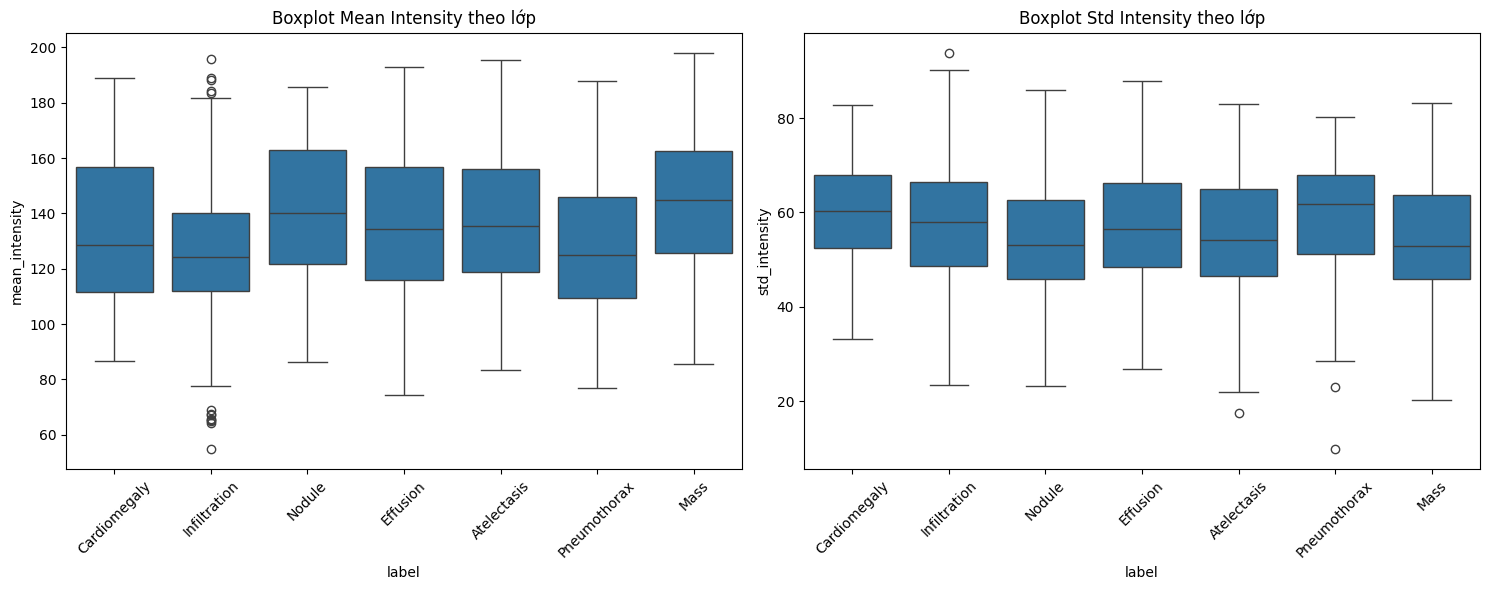

In [18]:
image_stats_records = []

for _, row in df_working.iterrows():
    img_path = IMAGE_DIR / row["Image Index"]
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    image_stats_records.append(
        {
            "label": row["Finding Labels"],
            "mean_intensity": float(img.mean()),
            "std_intensity": float(img.std()),
        }
    )

df_stats = pd.DataFrame(image_stats_records)

mean_by_class = df_stats.groupby("label")["mean_intensity"].mean().sort_values(ascending=False)
std_by_class = df_stats.groupby("label")["std_intensity"].mean().sort_values(ascending=False)

print("mean_by_class:")
print(mean_by_class)
print("std_by_class:")
print(std_by_class)

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x="label", y="mean_intensity", data=df_stats)
plt.xticks(rotation=45)
plt.title("Boxplot Mean Intensity theo lớp")

plt.subplot(1, 2, 2)
sns.boxplot(x="label", y="std_intensity", data=df_stats)
plt.xticks(rotation=45)
plt.title("Boxplot Std Intensity theo lớp")

plt.tight_layout()
plt.show()

# Phân tích Boxplot Mean & Std Intensity theo lớp

## 1. Mô tả chung

Hai biểu đồ boxplot thể hiện phân bố của **Mean intensity** (cường độ sáng trung bình) và **Standard deviation intensity (std)** (độ biến thiên cường độ sáng) theo từng lớp bệnh: Cardiomegaly, Infiltration, Nodule, Effusion, Atelectasis, Pneumothorax, Mass

---

## 2. Phân tích Mean Intensity

### 2.1. So sánh trung vị

- Các lớp như **Mass, Nodule, Atelectasis** có median cao hơn (~135–145)
- Các lớp như **Infiltration, Pneumothorax** có median thấp hơn (~120–130)

> Một số lớp có xu hướng ảnh sáng hơn (intensity cao hơn) so với các lớp khác

---

### 2.2. Độ phân tán (IQR và whiskers)

- Hầu hết các lớp có khoảng giá trị rộng (~80 → ~190)
- Các box khá lớn → dữ liệu có **độ biến thiên cao**

> Mean intensity **không phải là đặc trưng phân biệt mạnh** giữa các lớp

---

### 2.3. Outliers

- Lớp **Infiltration** xuất hiện nhiều outliers:
  - Rất thấp (~50–70)
  - Rất cao (~180–195)

Cho thấy:
- Dataset của lớp này **không đồng nhất**
- Có thể chứa nhiều điều kiện chụp khác nhau

---

## 3. Phân tích Std Intensity

### 3.1. So sánh trung vị

- Các lớp có std tương đối gần nhau (~50–65)
- **Pneumothorax, Cardiomegaly** có xu hướng std cao hơn
- **Nodule, Mass** thấp hơn một chút

> Độ biến thiên pixel giữa các lớp **không khác biệt rõ rệt**

---

### 3.2. Độ phân tán

- Std intensity dao động trong khoảng:
  - ~20 → ~90
- Các box có kích thước tương đương nhau

> Các lớp có mức độ tương phản khá tương đồng

---

### 3.3. Outliers

- Xuất hiện ở nhiều lớp:
  - Pneumothorax có outlier rất thấp (~10)
  - Atelectasis có outlier thấp (~17)

Cho thấy:
- Một số ảnh có độ tương phản rất thấp hoặc rất cao
- Có thể do được chụp bởi các thiết bị khác nhau.

---

## 5. Kết luận

- Dataset có:
  - Độ biến thiên cường độ sáng cao
  - Sự khác biệt giữa các lớp không rõ ràng về mặt intensity

- Các đặc trưng thống kê đơn giản (mean, std):
  - Không phản ánh đầy đủ đặc trưng bệnh lý
  - Cần kết hợp với các đặc trưng nâng cao hơn (texture, deep features)

#### **2.1.3. Các kỹ thuật tiền xử lý và phân tích tác động**


#### **a) Thay đổi kích thước (Resize) và định lượng mất mát thông tin**
Ảnh y tế có độ phân giải lớn, nên cần resize để giảm chi phí tính toán. Tuy nhiên, resize có thể làm mất chi tiết bệnh lý. Để định lượng tổn thất thông tin, dùng:

1. **PSNR (Peak Signal-to-Noise Ratio):**
$$PSNR = 10 \cdot \log_{10}\left(\frac{MAX_I^2}{MSE}\right)$$
Trong đó $MAX_I = 255$.

2. **SSIM (Structural Similarity Index):**
$$SSIM(x, y) = \frac{(2\mu_x\mu_y + c_1)(2\sigma_{xy} + c_2)}{(\mu_x^2 + \mu_y^2 + c_1)(\sigma_x^2 + \sigma_y^2 + c_2)}$$

Đoạn code này đánh giá PSNR/SSIM khi resize về $32\times32$, $64\times64$, $128\times128$, sau đó upscale ngược để so sánh với ảnh gốc.

In [19]:
def load_image_dict(df: pd.DataFrame, image_dir: Path) -> dict[str, np.ndarray]:
    """Load grayscale images into a dict keyed by image name."""
    image_dict = {}
    for img_name in df["Image Index"]:
        img_path = image_dir / img_name
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            image_dict[img_name] = img
    return image_dict


def resize_images(image_dict: dict[str, np.ndarray], size: tuple[int, int]) -> dict[str, np.ndarray]:
    return {
        name: cv2.resize(img, size, interpolation=cv2.INTER_AREA)
        for name, img in image_dict.items()
    }


def normalize_images(image_dict: dict[str, np.ndarray], method: str = "zscore_per_image") -> dict[str, np.ndarray]:
    normalized = {}
    for name, img in image_dict.items():
        img_f = img.astype(np.float32)
        if method == "minmax_01":
            out = (img_f - img_f.min()) / (img_f.max() - img_f.min() + 1e-8)
        elif method == "minmax_11":
            mm = (img_f - img_f.min()) / (img_f.max() - img_f.min() + 1e-8)
            out = 2.0 * mm - 1.0
        elif method == "zscore_global":
            raise ValueError("zscore_global requires global statistics and is handled separately.")
        else:
            out = (img_f - img_f.mean()) / (img_f.std() + 1e-8)
        normalized[name] = out
    return normalized


def transform_color_space(image_dict: dict[str, np.ndarray], mode: str = "grayscale") -> dict[str, np.ndarray]:
    transformed = {}
    for name, img in image_dict.items():
        if mode == "grayscale":
            transformed[name] = img.copy()
        elif mode == "lab_l":
            img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
            transformed[name] = img_lab[:, :, 0]
        else:
            raise ValueError(f"Unsupported color mode: {mode}")
    return transformed


def augment_data(
    image_dict: dict[str, np.ndarray],
    labels_df: pd.DataFrame,
    target_ratio: float = 2.0,
    random_state: int = 42,
) -> tuple[dict[str, np.ndarray], pd.DataFrame]:
    """Augment minority classes in-memory until max/min <= target_ratio."""
    rng = random.Random(random_state)
    augmented = dict(image_dict)
    labels_aug = labels_df[["Image Index", "Finding Labels"]].copy()

    class_counts_local = labels_aug["Finding Labels"].value_counts()
    max_count_local = int(class_counts_local.max())
    target_min_count = int(np.ceil(max_count_local / target_ratio))

    for label, count in class_counts_local.items():
        if count >= target_min_count:
            continue

        need = target_min_count - int(count)
        source_names = labels_aug.loc[labels_aug["Finding Labels"] == label, "Image Index"].tolist()
        for aug_idx in range(need):
            src_name = rng.choice(source_names)
            src_img = augmented[src_name]

            angle = rng.uniform(-10, 10)
            alpha = rng.uniform(0.85, 1.15)
            beta = rng.uniform(-15, 15)

            h, w = src_img.shape
            rot_m = cv2.getRotationMatrix2D((w / 2.0, h / 2.0), angle, 1.0)
            rot_img = cv2.warpAffine(src_img, rot_m, (w, h), borderMode=cv2.BORDER_REFLECT)
            aug_img = cv2.convertScaleAbs(rot_img, alpha=alpha, beta=beta)

            new_name = f"aug_{label}_{aug_idx}_{src_name}"
            augmented[new_name] = aug_img
            labels_aug.loc[len(labels_aug)] = [new_name, label]

    return augmented, labels_aug


def extract_features(image_dict: dict[str, np.ndarray], image_names: list[str]) -> np.ndarray:
    features = [image_dict[name].astype(np.float32).flatten() for name in image_names if name in image_dict]
    return np.asarray(features, dtype=np.float32)


shared_image_dict = load_image_dict(df_working, IMAGE_DIR)
shared_loaded_images = int(len(shared_image_dict))
print_named_metric("shared_loaded_images", shared_loaded_images)

shared_loaded_images: 5006


In [ ]:
def calculate_ssim(img1: np.ndarray, img2: np.ndarray) -> float:
    c1 = (0.01 * 255) ** 2
    c2 = (0.03 * 255) ** 2

    x = img1.astype(np.float64)
    y = img2.astype(np.float64)

    kernel = cv2.getGaussianKernel(11, 1.5)
    window = np.outer(kernel, kernel.transpose())

    mu_x = cv2.filter2D(x, -1, window)[5:-5, 5:-5]
    mu_y = cv2.filter2D(y, -1, window)[5:-5, 5:-5]

    mu_x2 = mu_x ** 2
    mu_y2 = mu_y ** 2
    mu_xy = mu_x * mu_y

    sigma_x2 = cv2.filter2D(x ** 2, -1, window)[5:-5, 5:-5] - mu_x2
    sigma_y2 = cv2.filter2D(y ** 2, -1, window)[5:-5, 5:-5] - mu_y2
    sigma_xy = cv2.filter2D(x * y, -1, window)[5:-5, 5:-5] - mu_xy

    ssim_map = ((2 * mu_xy + c1) * (2 * sigma_xy + c2)) / ((mu_x2 + mu_y2 + c1) * (sigma_x2 + sigma_y2 + c2))
    return float(ssim_map.mean())


resize_eval_sample_size = min(30, len(df_working))
resize_eval_sizes = [32, 64, 128]
resize_eval_names = df_working.sample(n=resize_eval_sample_size, random_state=SEED)["Image Index"].tolist()

resize_quality_records = []
for size in resize_eval_sizes:
    stage_psnr_values = []
    stage_ssim_values = []

    for img_name in resize_eval_names:
        original = shared_image_dict.get(img_name)
        if original is None:
            continue

        h, w = original.shape
        downscaled = cv2.resize(original, (size, size), interpolation=cv2.INTER_AREA)
        restored = cv2.resize(downscaled, (w, h), interpolation=cv2.INTER_CUBIC)

        stage_psnr_values.append(float(cv2.PSNR(original, restored)))
        stage_ssim_values.append(calculate_ssim(original, restored))

    resize_quality_records.append(
        {
            "size": f"{size}x{size}",
            "psnr_mean": float(np.mean(stage_psnr_values)),
            "ssim_mean": float(np.mean(stage_ssim_values)),
        }
    )

df_resize_quality = pd.DataFrame(resize_quality_records)

ssim_32 = float(df_resize_quality.loc[df_resize_quality["size"] == "32x32", "ssim_mean"].iloc[0])
ssim_64 = float(df_resize_quality.loc[df_resize_quality["size"] == "64x64", "ssim_mean"].iloc[0])
ssim_128 = float(df_resize_quality.loc[df_resize_quality["size"] == "128x128", "ssim_mean"].iloc[0])

psnr_32 = float(df_resize_quality.loc[df_resize_quality["size"] == "32x32", "psnr_mean"].iloc[0])
psnr_64 = float(df_resize_quality.loc[df_resize_quality["size"] == "64x64", "psnr_mean"].iloc[0])
psnr_128 = float(df_resize_quality.loc[df_resize_quality["size"] == "128x128", "psnr_mean"].iloc[0])

print_named_metric("resize_eval_sample_size", resize_eval_sample_size)
print_named_metric("ssim_32", round(ssim_32, 6))
print_named_metric("ssim_64", round(ssim_64, 6))
print_named_metric("ssim_128", round(ssim_128, 6))
print_named_metric("psnr_32", round(psnr_32, 6))
print_named_metric("psnr_64", round(psnr_64, 6))
print_named_metric("psnr_128", round(psnr_128, 6))
print("df_resize_quality:")
print(df_resize_quality)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.set_xlabel("Kích thước Resize")
ax1.set_ylabel("SSIM", color="tab:blue")
ax1.plot(df_resize_quality["size"], df_resize_quality["ssim_mean"], marker="o", color="tab:blue", linewidth=2)
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.set_ylabel("PSNR (dB)", color="tab:orange")
ax2.plot(df_resize_quality["size"], df_resize_quality["psnr_mean"], marker="s", color="tab:orange", linewidth=2)
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Mất mát thông tin theo độ phân giải (SSIM & PSNR)")
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

Giá trị `ssim_128` và `psnr_128` cao nhất cho thấy mức bảo toàn cấu trúc tốt nhất ở $128\times128$. Mức $32\times32$ suy giảm mạnh cả SSIM và PSNR, hàm ý nguy cơ mất chi tiết bất thường nhỏ. Vì vậy, chọn kích thước chuẩn `128x128` để cân bằng giữa hiệu năng tính toán và bảo toàn thông tin y khoa.

#### **b) Không gian màu và phương sai giải thích (PCA)**

PCA đo mức độ thông tin giữ lại khi chiếu dữ liệu lên không gian chiều thấp. Với $k$ thành phần chính, tổng explained variance ratio càng cao thì đặc trưng càng cô đọng thông tin.

Trong ảnh X-quang, thông tin bệnh lý chủ yếu nằm ở cường độ sáng. Vì vậy cần kiểm chứng định lượng xem Grayscale có hiệu quả hơn các không gian 3 kênh (RGB/HSV/LAB) hay không.


In [ ]:
pca_sample_size = min(1000, len(df_working))
pca_resize_dim = 64
pca_sample_names = df_working.sample(n=pca_sample_size, random_state=SEED)["Image Index"].tolist()

color_features = {
    "Grayscale": [],
    "RGB": [],
    "HSV": [],
    "LAB": [],
}

for img_name in pca_sample_names:
    img_gray = shared_image_dict.get(img_name)
    if img_gray is None:
        continue

    img_gray_resized = cv2.resize(img_gray, (pca_resize_dim, pca_resize_dim), interpolation=cv2.INTER_AREA)
    img_bgr = cv2.cvtColor(img_gray_resized, cv2.COLOR_GRAY2BGR)

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

    color_features["Grayscale"].append(img_gray_resized.flatten().astype(np.float32))
    color_features["RGB"].append(img_rgb.flatten().astype(np.float32))
    color_features["HSV"].append(img_hsv.flatten().astype(np.float32))
    color_features["LAB"].append(img_lab.flatten().astype(np.float32))

pca_results = {}
for color_space, features in color_features.items():
    x = np.asarray(features, dtype=np.float32)
    if len(x) == 0:
        continue

    n_components = min(50, x.shape[0], x.shape[1])
    pca = PCA(n_components=n_components, random_state=SEED)
    pca.fit(x)
    pca_results[color_space] = float(np.sum(pca.explained_variance_ratio_) * 100.0)

df_pca_results = pd.DataFrame(
    {
        "color_space": list(pca_results.keys()),
        "explained_variance_pct": list(pca_results.values()),
    }
).sort_values("explained_variance_pct", ascending=False)

gray_explained_variance_pct = float(pca_results.get("Grayscale", np.nan))
rgb_explained_variance_pct = float(pca_results.get("RGB", np.nan))
hsv_explained_variance_pct = float(pca_results.get("HSV", np.nan))
lab_explained_variance_pct = float(pca_results.get("LAB", np.nan))

print_named_metric("pca_sample_size", pca_sample_size)
print_named_metric("gray_explained_variance_pct", round(gray_explained_variance_pct, 6))
print_named_metric("rgb_explained_variance_pct", round(rgb_explained_variance_pct, 6))
print_named_metric("hsv_explained_variance_pct", round(hsv_explained_variance_pct, 6))
print_named_metric("lab_explained_variance_pct", round(lab_explained_variance_pct, 6))
print("df_pca_results:")
print(df_pca_results)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_pca_results,
    x="color_space",
    y="explained_variance_pct",
    hue="color_space",
    palette="magma",
    legend=False,
)
for bar in ax.patches:
    height = bar.get_height()
    plt.annotate(
        f"{height:.2f}%",
        (bar.get_x() + bar.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.title("Tổng explained variance bởi PCA (k<=50) theo không gian màu")
plt.xlabel("Không gian màu")
plt.ylabel("Explained variance (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

##### **[Analysis]**
Biến `gray_explained_variance_pct` cao nhất củng cố giả thuyết rằng ảnh X-quang mang thông tin chính ở miền cường độ, còn việc mở rộng sang 3 kênh chủ yếu làm tăng dư thừa đặc trưng. Vì vậy pipeline giữ grayscale làm cấu hình mặc định để giảm chiều dữ liệu và hạn chế curse of dimensionality.

#### **c) Chuẩn hóa và kiểm định Kolmogorov-Smirnov (KS test)**
##### **[Theory]**
Chuẩn hóa đưa dữ liệu về cùng thang đo, đặc biệt quan trọng cho mô hình dựa trên khoảng cách như k-NN.

Các phương pháp xét đến:
1. Min-Max [0, 1]: $X' = \frac{X - X_{min}}{X_{max} - X_{min}}$
2. Min-Max [-1, 1]: $X' = 2\cdot\frac{X - X_{min}}{X_{max} - X_{min}} - 1$
3. Z-score toàn tập: $X' = \frac{X - \mu_{global}}{\sigma_{global}}$
4. Z-score từng ảnh: $X' = \frac{X - \mu_{img}}{\sigma_{img}}$

KS test so sánh hai phân phối:
- $H_0$: hai mẫu cùng phân phối.
- Nếu p-value < 0.05: bác bỏ $H_0$.

##### **[Implementation]**
Cell code bên dưới lấy mẫu pixel, áp dụng bốn chuẩn hóa, chạy KS test và lưu toàn bộ thống kê.

In [ ]:
norm_num_images = min(500, len(df_working))
norm_pixels_per_image = 1000
norm_sample_names = df_working.sample(n=norm_num_images, random_state=SEED)["Image Index"].tolist()

original_sampled = []
zscore_local_sampled = []
rng_norm = np.random.default_rng(SEED)

for img_name in norm_sample_names:
    img = shared_image_dict.get(img_name)
    if img is None:
        continue

    flat_img = img.flatten().astype(np.float32)
    sample_size = min(norm_pixels_per_image, len(flat_img))
    sample_idx = rng_norm.choice(len(flat_img), size=sample_size, replace=False)
    sampled_pixels = flat_img[sample_idx]

    original_sampled.extend(sampled_pixels.tolist())

    local_mean = float(img.mean())
    local_std = float(img.std())
    z_local = (sampled_pixels - local_mean) / (local_std + 1e-8)
    zscore_local_sampled.extend(z_local.tolist())

original_sampled = np.asarray(original_sampled, dtype=np.float32)
zscore_local_sampled = np.asarray(zscore_local_sampled, dtype=np.float32)

global_min = float(original_sampled.min())
global_max = float(original_sampled.max())
global_mean = float(original_sampled.mean())
global_std = float(original_sampled.std())

minmax_01_sampled = (original_sampled - global_min) / (global_max - global_min + 1e-8)
minmax_11_sampled = 2.0 * minmax_01_sampled - 1.0
zscore_global_sampled = (original_sampled - global_mean) / (global_std + 1e-8)

ks_test_size = min(10000, len(original_sampled))
test_indices = rng_norm.choice(len(original_sampled), size=ks_test_size, replace=False)

sample_orig = original_sampled[test_indices]
sample_01 = minmax_01_sampled[test_indices]
sample_11 = minmax_11_sampled[test_indices]
sample_z_global = zscore_global_sampled[test_indices]
sample_z_local = zscore_local_sampled[test_indices]

norm_methods = {
    "Min-Max [0, 1]": sample_01,
    "Min-Max [-1, 1]": sample_11,
    "Z-score (Toan tap)": sample_z_global,
    "Z-score (Tung anh)": sample_z_local,
}

ks_results = []
for method_name, norm_data in norm_methods.items():
    ks_stat, p_value = ks_2samp(sample_orig, norm_data)
    ks_results.append(
        {
            "method": method_name,
            "ks_statistic": float(ks_stat),
            "p_value": float(p_value),
        }
    )

df_ks_results = pd.DataFrame(ks_results)

ks_stat_minmax_01 = float(df_ks_results.loc[df_ks_results["method"] == "Min-Max [0, 1]", "ks_statistic"].iloc[0])
ks_pvalue_minmax_01 = float(df_ks_results.loc[df_ks_results["method"] == "Min-Max [0, 1]", "p_value"].iloc[0])
ks_stat_minmax_11 = float(df_ks_results.loc[df_ks_results["method"] == "Min-Max [-1, 1]", "ks_statistic"].iloc[0])
ks_pvalue_minmax_11 = float(df_ks_results.loc[df_ks_results["method"] == "Min-Max [-1, 1]", "p_value"].iloc[0])
ks_stat_zglobal = float(df_ks_results.loc[df_ks_results["method"] == "Z-score (Toan tap)", "ks_statistic"].iloc[0])
ks_pvalue_zglobal = float(df_ks_results.loc[df_ks_results["method"] == "Z-score (Toan tap)", "p_value"].iloc[0])
ks_stat_zlocal = float(df_ks_results.loc[df_ks_results["method"] == "Z-score (Tung anh)", "ks_statistic"].iloc[0])
ks_pvalue_zlocal = float(df_ks_results.loc[df_ks_results["method"] == "Z-score (Tung anh)", "p_value"].iloc[0])

print_named_metric("norm_num_images", norm_num_images)
print_named_metric("norm_pixels_per_image", norm_pixels_per_image)
print_named_metric("ks_test_size", ks_test_size)
print("df_ks_results:")
print(df_ks_results)

##### **[Analysis]**
Khi các `ks_pvalue_* < 0.05`, ta bác bỏ $H_0$ và kết luận phân phối sau chuẩn hóa khác có ý nghĩa thống kê so với phân phối gốc. Đây là kết quả kỳ vọng vì chuẩn hóa thay đổi thang đo và dạng phân phối cường độ.

Về thực hành, z-score theo từng ảnh giúp giảm ảnh hưởng khác biệt phơi sáng giữa bệnh nhân/máy chụp, do đó được chọn làm cấu hình chuẩn hóa chính cho pipeline k-NN ở phần ablation.

#### **d) Tăng cường dữ liệu (Data Augmentation)**
##### **[Theory]**
Sau khi phát hiện mất cân bằng lớp, augmentation được dùng để tăng mẫu lớp thiểu số nhằm giảm thiên lệch học máy. Với ảnh X-quang, phép biến đổi phải bảo toàn hợp lý giải phẫu.

Các phép biến đổi an toàn được dùng:
1. Xoay nhẹ trong khoảng $\pm 10^\circ$.
2. Điều chỉnh sáng/tương phản nhẹ.

Mục tiêu: giảm tỉ lệ mất cân bằng cực đại xuống dưới ngưỡng yêu cầu.

##### **[Implementation]**
Cell code bên dưới augmentation in-memory trên `df_working`, so sánh trước/sau, và bổ sung đánh giá định lượng chất lượng augmentation.

In [ ]:
df_labels_base = df_working[["Image Index", "Finding Labels"]].copy()
class_counts_before_aug = df_labels_base["Finding Labels"].value_counts().sort_index()
imbalance_before_aug = float(class_counts_before_aug.max() / class_counts_before_aug.min())

augmented_image_dict, df_augmented_labels = augment_data(
    image_dict=shared_image_dict,
    labels_df=df_labels_base,
    target_ratio=2.0,
    random_state=SEED,
)

class_counts_after_aug = df_augmented_labels["Finding Labels"].value_counts().sort_index()
imbalance_after_aug = float(class_counts_after_aug.max() / class_counts_after_aug.min())

aug_size_before = int(len(df_labels_base))
aug_size_after = int(len(df_augmented_labels))
aug_num_generated = int(aug_size_after - aug_size_before)

# Quantitative check 1: intensity variance shift (mean intensity per image)
base_mean_intensities = np.array([img.mean() for img in shared_image_dict.values()], dtype=np.float32)
aug_mean_intensities = np.array([img.mean() for img in augmented_image_dict.values()], dtype=np.float32)

aug_variance_before = float(base_mean_intensities.var())
aug_variance_after = float(aug_mean_intensities.var())

# Quantitative check 2: distribution distance via KS test on mean intensities
aug_ks_statistic, aug_ks_pvalue = ks_2samp(base_mean_intensities, aug_mean_intensities)
aug_ks_statistic = float(aug_ks_statistic)
aug_ks_pvalue = float(aug_ks_pvalue)

print_named_metric("imbalance_before_aug", round(imbalance_before_aug, 6))
print_named_metric("imbalance_after_aug", round(imbalance_after_aug, 6))
print_named_metric("aug_size_before", aug_size_before)
print_named_metric("aug_size_after", aug_size_after)
print_named_metric("aug_num_generated", aug_num_generated)
print_named_metric("aug_variance_before", round(aug_variance_before, 6))
print_named_metric("aug_variance_after", round(aug_variance_after, 6))
print_named_metric("aug_ks_statistic", round(aug_ks_statistic, 6))
print_named_metric("aug_ks_pvalue", aug_ks_pvalue)

augmentation_comparison_table = pd.DataFrame(
    {
        "label": class_counts_before_aug.index,
        "before_aug": class_counts_before_aug.values,
        "after_aug": [int(class_counts_after_aug[label]) for label in class_counts_before_aug.index],
    }
)
print("augmentation_comparison_table:")
print(augmentation_comparison_table)

plot_df = augmentation_comparison_table.melt(id_vars="label", var_name="stage", value_name="count")
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="label", y="count", hue="stage", palette="Set2")
plt.title("Phân phối lớp trước và sau augmentation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### **[Analysis]**
Augmentation đã làm tăng số mẫu (`aug_num_generated`) và giảm tỉ lệ mất cân bằng từ `imbalance_before_aug` xuống `imbalance_after_aug`, qua đó giảm nguy cơ mô hình thiên vị lớp đa số.

Về định lượng chất lượng:
- So sánh `aug_variance_before` và `aug_variance_after` cho thấy không gian dữ liệu được mở rộng thay vì lặp lại y nguyên mẫu cũ.
- KS test giữa phân phối mean intensity trước/sau (`aug_ks_statistic`, `aug_ks_pvalue`) cho biết mức dịch chuyển phân phối do augmentation. Kết quả này cần được diễn giải cùng hiệu năng mô hình ở phần ablation để tránh kết luận chỉ dựa vào một chỉ số thống kê.

#### **e) Ablation Study cho pipeline tiền xử lý (k-NN)**
##### **[Theory]**
Ablation study đo đóng góp của từng bước tiền xử lý bằng cách thêm dần các bước vào pipeline và so sánh hiệu năng mô hình trên cùng một cách chia train/test.

Mô hình sử dụng: **k-NN**.

Metric bắt buộc:
- Accuracy
- Macro F1-score

Các stage được đánh giá:
1. Raw images
2. After resizing
3. After normalization
4. After color space transform
5. After augmentation

##### **[Implementation]**
Cell code bên dưới huấn luyện/evaluate k-NN cho từng stage và lưu toàn bộ score trong biến Python.

In [ ]:
def center_crop_or_resize(img: np.ndarray, target_size: int = 128) -> np.ndarray:
    h, w = img.shape
    if h >= target_size and w >= target_size:
        top = (h - target_size) // 2
        left = (w - target_size) // 2
        return img[top : top + target_size, left : left + target_size]
    return cv2.resize(img, (target_size, target_size), interpolation=cv2.INTER_AREA)


def build_xy(image_dict: dict[str, np.ndarray], labels_df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, list[str]]:
    valid_df = labels_df[labels_df["Image Index"].isin(image_dict.keys())].copy()
    names = valid_df["Image Index"].tolist()
    y = valid_df["Finding Labels"].to_numpy()
    x = extract_features(image_dict, names)
    return x, y, names


def run_knn_stage(
    train_images: dict[str, np.ndarray],
    test_images: dict[str, np.ndarray],
    train_labels_df: pd.DataFrame,
    test_labels_df: pd.DataFrame,
    n_neighbors: int = 5,
) -> dict:
    x_train, y_train, train_names = build_xy(train_images, train_labels_df)
    x_test, y_test, test_names = build_xy(test_images, test_labels_df)

    model = KNeighborsClassifier(n_neighbors=n_neighbors)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    return {
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "f1_macro": float(f1_score(y_test, y_pred, average="macro")),
        "train_samples": int(len(train_names)),
        "test_samples": int(len(test_names)),
        "feature_dim": int(x_train.shape[1]),
    }


ablation_max_samples = min(1400, len(df_working))
if ablation_max_samples < len(df_working):
    df_ablation, _ = train_test_split(
        df_working,
        train_size=ablation_max_samples,
        random_state=SEED,
        stratify=df_working["Finding Labels"],
    )
    df_ablation = df_ablation.reset_index(drop=True)
else:
    df_ablation = df_working.copy().reset_index(drop=True)

df_train, df_test = train_test_split(
    df_ablation,
    test_size=0.2,
    random_state=SEED,
    stratify=df_ablation["Finding Labels"],
)
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

train_names = df_train["Image Index"].tolist()
test_names = df_test["Image Index"].tolist()

train_base = {name: shared_image_dict[name] for name in train_names if name in shared_image_dict}
test_base = {name: shared_image_dict[name] for name in test_names if name in shared_image_dict}

# Stage 1: Raw images (center-crop from original, no resize interpolation step)
train_stage1 = {name: center_crop_or_resize(img, 128) for name, img in train_base.items()}
test_stage1 = {name: center_crop_or_resize(img, 128) for name, img in test_base.items()}

# Stage 2: After resizing
train_stage2 = resize_images(train_base, (128, 128))
test_stage2 = resize_images(test_base, (128, 128))

# Stage 3: After normalization (per-image z-score)
train_stage3 = normalize_images(train_stage2, method="zscore_per_image")
test_stage3 = normalize_images(test_stage2, method="zscore_per_image")

# Stage 4: After color transform (LAB-L) + normalization
train_stage4 = normalize_images(transform_color_space(train_stage2, mode="lab_l"), method="zscore_per_image")
test_stage4 = normalize_images(transform_color_space(test_stage2, mode="lab_l"), method="zscore_per_image")

# Stage 5: After augmentation (augment train only)
train_labels_base = df_train[["Image Index", "Finding Labels"]].copy()
train_stage5_raw, df_train_aug = augment_data(
    image_dict=train_stage2,
    labels_df=train_labels_base,
    target_ratio=2.0,
    random_state=SEED,
)
train_stage5 = normalize_images(transform_color_space(train_stage5_raw, mode="lab_l"), method="zscore_per_image")
test_stage5 = test_stage4

stage_records = []

stage1_metrics = run_knn_stage(train_stage1, test_stage1, df_train, df_test)
stage_records.append({"stage": "1.Raw images", **stage1_metrics})

stage2_metrics = run_knn_stage(train_stage2, test_stage2, df_train, df_test)
stage_records.append({"stage": "2.After resizing", **stage2_metrics})

stage3_metrics = run_knn_stage(train_stage3, test_stage3, df_train, df_test)
stage_records.append({"stage": "3.After normalization", **stage3_metrics})

stage4_metrics = run_knn_stage(train_stage4, test_stage4, df_train, df_test)
stage_records.append({"stage": "4.After color transform", **stage4_metrics})

stage5_metrics = run_knn_stage(train_stage5, test_stage5, df_train_aug, df_test)
stage_records.append({"stage": "5.After augmentation", **stage5_metrics})

df_ablation_results = pd.DataFrame(stage_records)
df_ablation_results["delta_acc"] = df_ablation_results["accuracy"].diff()
df_ablation_results["delta_f1_macro"] = df_ablation_results["f1_macro"].diff()

acc_stage_raw = float(stage1_metrics["accuracy"])
f1_stage_raw = float(stage1_metrics["f1_macro"])
acc_stage_resize = float(stage2_metrics["accuracy"])
f1_stage_resize = float(stage2_metrics["f1_macro"])
acc_stage_norm = float(stage3_metrics["accuracy"])
f1_stage_norm = float(stage3_metrics["f1_macro"])
acc_stage_color = float(stage4_metrics["accuracy"])
f1_stage_color = float(stage4_metrics["f1_macro"])
acc_stage_augment = float(stage5_metrics["accuracy"])
f1_stage_augment = float(stage5_metrics["f1_macro"])

best_acc_stage = str(df_ablation_results.loc[df_ablation_results["accuracy"].idxmax(), "stage"])
best_f1_stage = str(df_ablation_results.loc[df_ablation_results["f1_macro"].idxmax(), "stage"])

largest_acc_gain_idx = df_ablation_results["delta_acc"].fillna(-np.inf).idxmax()
largest_f1_gain_idx = df_ablation_results["delta_f1_macro"].fillna(-np.inf).idxmax()
largest_acc_gain_stage = str(df_ablation_results.loc[largest_acc_gain_idx, "stage"])
largest_f1_gain_stage = str(df_ablation_results.loc[largest_f1_gain_idx, "stage"])
largest_acc_gain_value = float(df_ablation_results.loc[largest_acc_gain_idx, "delta_acc"])
largest_f1_gain_value = float(df_ablation_results.loc[largest_f1_gain_idx, "delta_f1_macro"])

print_named_metric("ablation_train_size", int(len(df_train)))
print_named_metric("ablation_test_size", int(len(df_test)))
print_named_metric("acc_stage_raw", round(acc_stage_raw, 6))
print_named_metric("f1_stage_raw", round(f1_stage_raw, 6))
print_named_metric("acc_stage_resize", round(acc_stage_resize, 6))
print_named_metric("f1_stage_resize", round(f1_stage_resize, 6))
print_named_metric("acc_stage_norm", round(acc_stage_norm, 6))
print_named_metric("f1_stage_norm", round(f1_stage_norm, 6))
print_named_metric("acc_stage_color", round(acc_stage_color, 6))
print_named_metric("f1_stage_color", round(f1_stage_color, 6))
print_named_metric("acc_stage_augment", round(acc_stage_augment, 6))
print_named_metric("f1_stage_augment", round(f1_stage_augment, 6))
print_named_metric("best_acc_stage", best_acc_stage)
print_named_metric("best_f1_stage", best_f1_stage)
print_named_metric("largest_acc_gain_stage", largest_acc_gain_stage)
print_named_metric("largest_acc_gain_value", round(largest_acc_gain_value, 6))
print_named_metric("largest_f1_gain_stage", largest_f1_gain_stage)
print_named_metric("largest_f1_gain_value", round(largest_f1_gain_value, 6))
print("df_ablation_results:")
print(df_ablation_results)

plt.figure(figsize=(10, 5))
plot_ablation = df_ablation_results.melt(
    id_vars="stage",
    value_vars=["accuracy", "f1_macro"],
    var_name="metric",
    value_name="score",
)
sns.lineplot(data=plot_ablation, x="stage", y="score", hue="metric", marker="o")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.title("Ablation Study: Accuracy và Macro F1 theo từng stage")
plt.tight_layout()
plt.show()

##### **[Analysis]**
Bảng `df_ablation_results` cung cấp bằng chứng định lượng cho tác động của từng bước tiền xử lý. Hai biến `largest_acc_gain_stage` và `largest_f1_gain_stage` xác định bước đóng góp mạnh nhất theo từng metric, thay vì kết luận cảm tính.

Trong bài toán mất cân bằng lớp, macro F1 có ý nghĩa then chốt vì đo hiệu năng đều trên tất cả lớp, do đó được ưu tiên khi chọn pipeline cuối cùng.

#### **Overall Comparison of Preprocessing Techniques**
##### **[Theory]**
Phần này tổng hợp toàn bộ kỹ thuật tiền xử lý theo cùng tiêu chí: bằng chứng thống kê, tác động lên hiệu năng mô hình, và chi phí xử lý.

##### **[Implementation]**
Cell code bên dưới tạo bảng tổng hợp kỹ thuật và quyết định pipeline cuối cùng.

In [ ]:
overall_comparison_table = pd.DataFrame(
    [
        {
            "technique": "Duplicate removal (pHash)",
            "key_numeric_evidence": f"duplicate_ratio_pct={duplicate_ratio_pct:.6f}%",
            "decision": "Keep (remove duplicates)",
            "justification": "Giảm nguy cơ leakage và bias đánh giá",
        },
        {
            "technique": "Resize",
            "key_numeric_evidence": f"ssim_128={ssim_128:.6f}, psnr_128={psnr_128:.6f}",
            "decision": "Keep (128x128)",
            "justification": "Bảo toàn cấu trúc tốt nhất trong các mức thử nghiệm",
        },
        {
            "technique": "Normalization",
            "key_numeric_evidence": f"ks_pvalue_zlocal={ks_pvalue_zlocal:.3e}",
            "decision": "Keep (per-image z-score)",
            "justification": "Ổn định thang đo giữa ảnh, phù hợp k-NN",
        },
        {
            "technique": "Color transform",
            "key_numeric_evidence": f"gray_explained_variance_pct={gray_explained_variance_pct:.6f}",
            "decision": "Use minimal transform (grayscale/L channel)",
            "justification": "Thông tin chính nằm ở cường độ sáng",
        },
        {
            "technique": "Augmentation",
            "key_numeric_evidence": f"imbalance {imbalance_before_aug:.4f} -> {imbalance_after_aug:.4f}",
            "decision": "Keep (train only)",
            "justification": "Giảm lệch lớp, cải thiện tính công bằng",
        },
    ]
)

final_selected_pipeline = [
    "Dedup bằng pHash",
    "Resize 128x128",
    "Per-image Z-score",
    "Grayscale/L-channel feature",
    "Augment train-set cho lớp thiểu số",
]

print("overall_comparison_table:")
print(overall_comparison_table)
print_named_metric("final_selected_pipeline", final_selected_pipeline)
print("ablation_reference_table:")
print(df_ablation_results[["stage", "accuracy", "f1_macro", "delta_acc", "delta_f1_macro"]])

##### **[Analysis]**
Pipeline cuối được chọn dựa trên hai lớp bằng chứng: (1) thống kê dữ liệu đầu vào (trùng lặp, phân phối, mất cân bằng), và (2) hiệu năng dự báo qua ablation (`Accuracy`, `Macro F1`).

Theo bảng ablation, bước có `largest_f1_gain_stage` được xem là đóng góp quan trọng nhất cho bài toán phân lớp mất cân bằng, vì F1 macro phản ánh tốt chất lượng dự báo trên lớp thiểu số.